# Multi-Year-on-Year Example


This Jupyter notebook follows on from the existing TrendAnalysis_example.ipynb and assumes familiarity with that example. This
example investigates an additional piece of functionality introduced in RdTools 3.2.0: multi-year-on-year analysis.

The calculations consist of:

1. Import and preliminary calculations: In this step data is imported and augmented to enable analysis with RdTools. **No RdTools functions are used in this step. It will vary depending on the particulars of your dataset.**  
2. Analysis with RdTools: This notebook illustrates the use of the TrendAnalysis API with the new feature: `multi_yoy=True`. Because we are implementing this with the `rdtools.TrendAnalysis` object-oriented API, it requires passing kwargs to `degradation_year_on_year` as a dictionary in the `TrendAnalysis.sensor_analysis(yoy_kwargs={})` input.

For a consistent experience, we recommend using [pixi](https://pixi.sh) to set up the notebook environment. From the base directory, run `pixi run -e notebooks lab` to launch JupyterLab with all required packages. Alternatively, install manually with `pip install rdtools[notebooks]`. This notebook was tested in python 3.13.

This notebook works with data from the NREL PVDAQ `[4] NREL x-Si #1` system. This notebook automatically downloads and locally caches the dataset used in this example. The data can also be found on the rdtools GitHub repo (https://github.com/NatLabRockies/rdtools/releases/download/3.0.0/pvdaq_system_4_2010-2016_subset_soil_signal.csv).


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pvlib
import rdtools
%matplotlib inline

In [2]:
#Update the style of plots
import matplotlib
matplotlib.rcParams.update({'font.size': 12,
                           'figure.figsize': [4.5, 3],
                           'lines.markeredgewidth': 0,
                           'lines.markersize': 2
                           })
# Register time series plotting in pandas > 1.0
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

In [3]:
# Set the random seed for numpy to ensure consistent results
np.random.seed(0)

## Import and preliminary calculations


This section prepares the data necessary for an `rdtools.TrendAnalysis` calculation.

A common challenge is handling datasets with and without daylight savings time. Make sure to specify a `pytz` timezone that does or does not include daylight savings time as appropriate for your dataset.

**The steps of this section may change depending on your data source or the system being considered. Note that nothing in this first section utilizes the `rdtools` library.** Transposition of irradiance and modeling of cell temperature are generally outside the scope of `rdtools`. A variety of tools for these calculations are available in [pvlib](https://github.com/pvlib/pvlib-python).

In [4]:
# Import the example data
file_url = ('https://github.com/NatLabRockies/rdtools/releases/download/3.0.0/'
            'pvdaq_system_4_2010-2016_subset_soil_signal.csv')
cache_file = 'PVDAQ_system_4_2010-2016_subset_soilsignal.pickle'

try:
    df = pd.read_pickle(cache_file)
except FileNotFoundError:
    df = pd.read_csv(file_url, index_col=0, parse_dates=True)
    df.to_pickle(cache_file)

In [5]:
df = df.rename(columns = {
    'ac_power':'power_ac',
    'wind_speed': 'wind_speed',
    'ambient_temp': 'Tamb',
    'poa_irradiance': 'poa',
})

# Specify the Metadata
meta = {"latitude": 39.7406,
        "longitude": -105.1774,
        "timezone": 'Etc/GMT+7',
        "gamma_pdc": -0.0034,  # Temperature coefficient for modern silicon PV modules (1/K)
        "azimuth": 180,
        "tilt": 40,
        "power_dc_rated": 1000.0,
        "temp_model_params":'open_rack_glass_polymer'}

df.index = df.index.tz_localize(meta['timezone'])

# Set the pvlib location
loc = pvlib.location.Location(meta['latitude'], meta['longitude'], tz = meta['timezone'])

# There is some missing data, but we can infer the frequency from
# the first several data points
freq = pd.infer_freq(df.index[:10])

Note: Unlike the original notebook, we are not incorporating soiling into this analysis and are focusing on year-on-year degradation

## Use of the object oriented system analysis API

The first step is to create a `TrendAnalysis` instance containing data to be analyzed and information about the system. The new functionality is accessed in a following step when calling the `sensor_analysis()` method.

In [6]:
ta = rdtools.TrendAnalysis(df['power_ac'], df['poa'],
                           temperature_ambient=df['Tamb'],
                           gamma_pdc=meta['gamma_pdc'],
                           interp_freq=freq,
                           windspeed=df['wind_speed'],
                           power_dc_rated=meta['power_dc_rated'],
                           temperature_model=meta['temp_model_params'])

Once the `TrendAnalysis` object is ready, the `sensor_analysis()` method can be used to deploy the full chain of analysis steps. Results are stored in a nested dict, `TrendAnalysis.results`.

In [7]:
ta.sensor_analysis(analyses=['yoy_degradation'])

The results of the calculations are stored in a nested dict, `TrendAnalysis.results`. New keys are stored in the `calc_info` dictionary: `YoY_times` provides the left, right, and center label for each calculated slope. This provides important context for the next step, which is multi-YoY calculation. 

In [8]:
# Print the YoY slopes. Timestamps are right-labeled.
calc_info = ta.results['sensor']['yoy_degradation']['calc_info']
print(calc_info['YoY_values'].head().to_markdown())

|   dt |     yoy |
|-----:|--------:|
|  366 | 31.7242 |
|  367 | 21.4746 |
|  368 | 20.9898 |
|  369 | 25.8811 |
|  371 | 21.3218 |


In [9]:
# Provide additional timestamp information for the YoY slopes including the left and right timestamps that were used to calculate the slope.
# The index is set equal to dt_right by default.
print(calc_info['YoY_times'].head().to_markdown())

|   dt | dt_right                  | dt_center                 | dt_left                   |
|-----:|:--------------------------|:--------------------------|:--------------------------|
|  366 | 2011-02-26 00:00:00-07:00 | 2010-08-27 12:00:00-07:00 | 2010-02-26 00:00:00-07:00 |
|  367 | 2011-02-27 00:00:00-07:00 | 2010-08-28 12:00:00-07:00 | 2010-02-27 00:00:00-07:00 |
|  368 | 2011-02-28 00:00:00-07:00 | 2010-08-29 12:00:00-07:00 | 2010-02-28 00:00:00-07:00 |
|  369 | 2011-03-01 00:00:00-07:00 | 2010-08-30 12:00:00-07:00 | 2010-03-01 00:00:00-07:00 |
|  371 | 2011-03-03 00:00:00-07:00 | 2010-09-01 12:00:00-07:00 | 2010-03-03 00:00:00-07:00 |


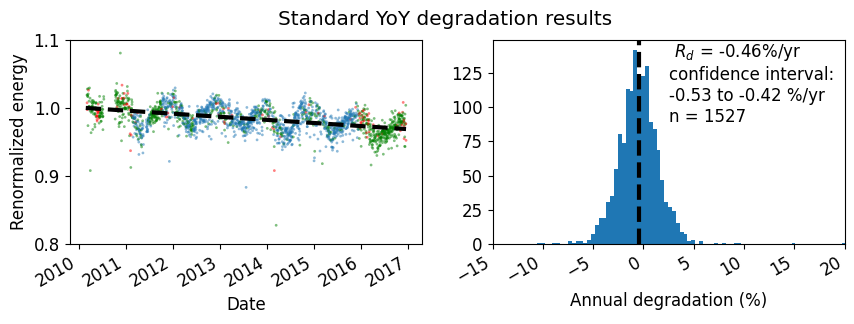

In [10]:
# plot the standard YoY degradation plot to compare with the multi-YoY plot later
ta.plot_degradation_summary('sensor', summary_title='Standard YoY degradation results',
                                  scatter_ymin=0.8, scatter_ymax=1.1, detailed=True,
                                  hist_xmin=-15, hist_xmax=20, bins=500)
plt.show()

In the above plot with `detailed=True`, note that points in red are not included in the analysis because there is no matching start or endpoint 365 days away. Points in green are used only once, either as a start-point or end-point, but not both.  

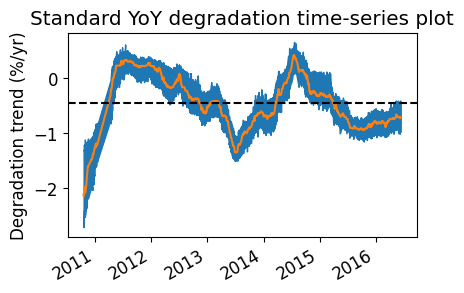

In [11]:
# plot the standard YoY time-series plot to compare with the multi-YoY plot later
ta.plot_degradation_timeseries(case='sensor', center=True, min_periods_divisor=4)
plt.title('Standard YoY degradation time-series plot')
plt.show()

### Multi-YoY analysis

By passing `multi_yoy=True` instead of the default `False`, we now trigger multi-YoY slope measurements. This follows the method of Quest et al., 2023.<sup>1</sup> Instead of the standard year-on-year slopes where each slope is calculated over points separated by 365 days, the multi-year-on-year approach includes multiple slopes where points can be separated by N × 365 days where N is an integer from 1 to the length of the dataset in years. Continuing our above example, if our dataset extends from 2020 to 2024, slopes beginning on '2020-01-01' will include slopes calculated to the following endpoints: '2021-01-01', '2022-01-01', '2023-01-01', and '2024-01-01'. Slopes are still calculated in equivalent units of % / year, but now multiple values will occupy the same index.

<sup>1</sup>H. Quest, C. Ballif, A. Virtuani, "Multi‐Annual Year‐on‐Year: Minimising the Uncertainty in Photovoltaic System Performance Loss Rates," Progress in Photovoltaics: Research and Applications, vol. 33, no. 3, pp. 411-424, Oct. 2024. doi: 10.1002/pip.3855

In [12]:
ta.sensor_analysis(analyses=['yoy_degradation'], yoy_kwargs={'multi_yoy': True})

In [13]:
calc_info_multi = ta.results['sensor']['yoy_degradation']['calc_info']


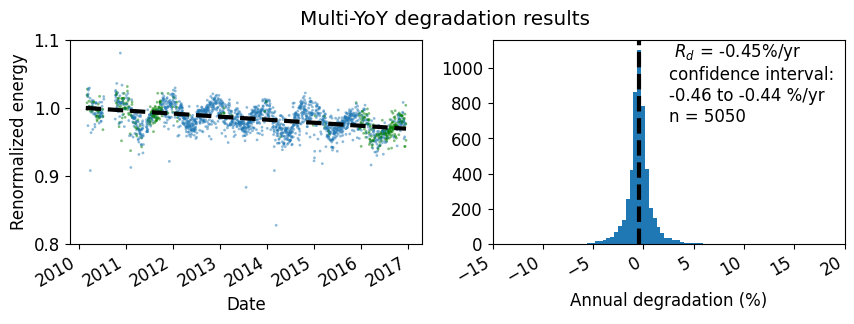

Multi-YoY number of slopes: 5050
Standard method number of slopes: 1527


In [14]:
# plot the multi-YoY degradation plot to compare with the multi-YoY plot later
ta.plot_degradation_summary('sensor', summary_title='Multi-YoY degradation results',
                                  scatter_ymin=0.8, scatter_ymax=1.1, detailed=True,
                                  hist_xmin=-15, hist_xmax=20, bins=500)
plt.show()
print(f'Multi-YoY number of slopes: {calc_info_multi["YoY_values"].__len__()}')
print(f'Standard method number of slopes: {calc_info["YoY_values"].__len__()}')

In the multi-YoY approach, we generate a larger number of slopes and datapoints from the same dataset. Note that n=5050 instead of n=1527 from the conventional approach. This tightens our confidence interval for overall degradation assessment.

Also, with `detailed=True` showing which points are included in the analysis, none of the datapoints are red, indicating that even if there is a data outage one year removed from the point, there is some other datapoint within an integer number N × years to be included in the distribution.

Next we look at the time-dependent degradation plot, which will average the multi-year slopes if `multi_yoy=True`.  

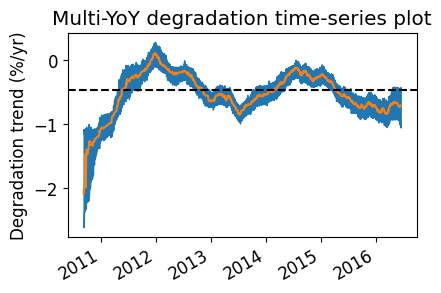

In [15]:
# Plot the multi-YoY time-series plot.
# The method will automatically average all datapoints sharing a timestamp. The result is a more filtered annual trend.
ta.plot_degradation_timeseries(case='sensor', center=True, min_periods_divisor=4)
plt.title('Multi-YoY degradation time-series plot')
plt.show()

### Further illustration
To further illustrate the details of multi-YoY operation, 
we consider the below multi-YoY example.  Here we look at five slopes, each of which have the same
center-labeled datapoint in 2013.  These consist of 1,2,3,4 and 5-year segment lengths,
each of which has a midpoint of the segment coinciding with the same timestamp. 
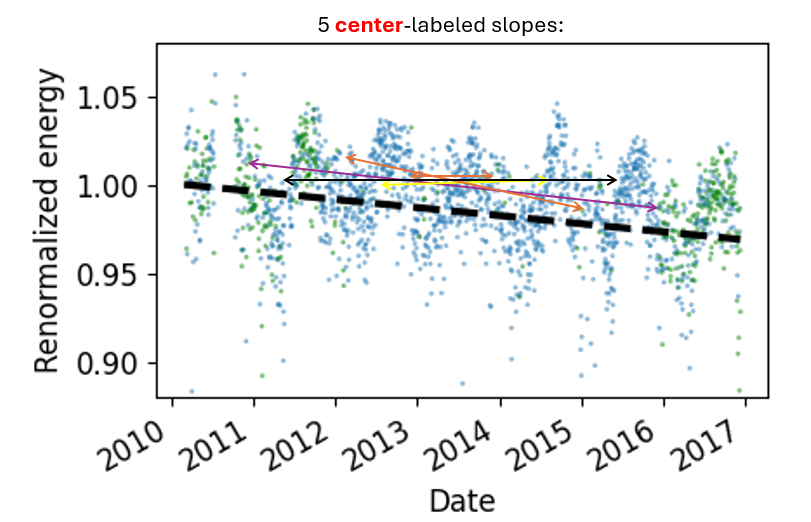

For the degradation summary plot, each of the multi-year slopes will be included in the histogram.  
For the time-series degradation plot, a moving window (1-year width by default) will include slope values whose
center-point falls within the window.  A median of all included slopes is assigned at the center of the window.